# Distribution des continents dans le temps 

Dans ce carnet est proposée une analyse de la distribution dans le temps des continents relatifs aux pays d'appartenance, en relation aux années de naissance de la population retenue.


In [122]:
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
### Librairies déjà installées avec Python
import pprint
import csv
import sys

import time
import datetime
from dateutil import parser
from shutil import copyfile


In [3]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

We use in this notebook the data produced in the da2 chapter, i.e. a list of persons with birth year, gender, place of birth, world region of birth

In [4]:
csv_address='da_data/da3-birthYear-gender-region.csv'
df_p = pd.read_csv(csv_address)
df_p.head()

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe
2,http://www.wikidata.org/entity/Q100153910,Frank J. Blatt,1924,male,Vienna,POINT (16.3725 48.208333),http://www.wikidata.org/entity/Q1741,22,Western Europe
3,http://www.wikidata.org/entity/Q100155322,Edgar Knobloch,1953,male,Prague,POINT (14.421389 50.0875),http://www.wikidata.org/entity/Q1085,8,Eastern Europe
4,http://www.wikidata.org/entity/Q100169285,Robert M. Winglee,1958,male,Sydney,POINT (151.21 -33.867778),http://www.wikidata.org/entity/Q3130,2,Australia/New Zealand


In [5]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21445 entries, 0 to 21444
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uriPer      21445 non-null  object
 1   labelPer    21445 non-null  object
 2   birthYear   21445 non-null  int64 
 3   gender      21351 non-null  object
 4   labelPlace  21445 non-null  object
 5   geometry    21445 non-null  object
 6   uriPlace    21445 non-null  object
 7   FID         21445 non-null  int64 
 8   REGION      21445 non-null  object
dtypes: int64(2), object(7)
memory usage: 1.5+ MB


## Distribution of regions of birth

In [6]:
### Regrouper et compter
df_region = df_p.groupby('REGION').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)



                       number
REGION                       
Western Europe           5538
Eastern Europe           4548
Northern America         2795
Southern Europe          1935
Northern Europe          1687
European Russia          1665
Eastern Asia              862
Western Asia              621
Southern Asia             445
South America             337
Asiatic Russia            293
Australia/New Zealand     190
Central Asia              182
Northern Africa            95
Central America            88
Southeastern Asia          51
Southern Africa            47
Western Africa             27
Caribbean                  16
Eastern Africa             13
Middle Africa               6
Polynesia                   2
Micronesia                  2


In [7]:
### We define a function that codes and aggregates our values

def codeRegion(region: str):
    if ' Africa' in region:
        output='Africa'
    elif 'Russia' in region:
        output='Russia'
    elif 'Asia' in region:
        output='Asia'
    elif 'Austral' in region \
        or 'Polyn' in region \
        or 'Micron' in region:
        output='Australia/Ilands'
    elif 'Northern America' in region:
        output='America North'
    elif ' America' in region:
        output='America Central/South'
    elif 'Caribb' in region:
        output='America Central/South'
    else:
        output=region
    return output                   

In [8]:
# r='Southern Africa'
# r='Central Asia'
r='Asiatic Russia'
codeRegion(r)

'Russia'

In [9]:
df_p['coded_region']=df_p.REGION.apply(lambda x : codeRegion(x))

In [10]:
### Regrouper et compter
df_region = df_p.groupby('coded_region').size()
df_region = pd.DataFrame(df_region.sort_values(ascending = False))
#df_contCode.reset_index(inplace=True)
df_region.columns=['number']
print(df_region)



                       number
coded_region                 
Western Europe           5538
Eastern Europe           4548
America North            2795
Asia                     2161
Russia                   1958
Southern Europe          1935
Northern Europe          1687
America Central/South     441
Australia/Ilands          194
Africa                    188


In [11]:
### Add frequency

df_region['frequency'] = (100 * df_region['number'] \
                                   / df_region['number'].sum()).round(2)
df_region



,number,frequency
coded_region,,
Western Europe,5538,25.82
Eastern Europe,4548,21.21
America North,2795,13.03
Asia,2161,10.08
Russia,1958,9.13
Southern Europe,1935,9.02
Northern Europe,1687,7.87
America Central/South,441,2.06
Australia/Ilands,194,0.90


In [12]:
### Transform to one row dataframe
ljt = pd.DataFrame(df_region['frequency'].sort_values(ascending=False)).T
ljt



coded_region,Western Europe,Eastern Europe,America North,Asia,Russia,Southern Europe,Northern Europe,America Central/South,Australia/Ilands,Africa
frequency,25.82,21.21,13.03,10.08,9.13,9.02,7.87,2.06,0.9,0.88


In [13]:
### Créer une palette de couleurs
colors = plt.cm.tab20(range(10))
print(colors[:2], '\n', colors[-2:])

[[0.12156863 0.46666667 0.70588235 1.        ]
 [0.68235294 0.78039216 0.90980392 1.        ]] 
 [[0.58039216 0.40392157 0.74117647 1.        ]
 [0.77254902 0.69019608 0.83529412 1.        ]]


In [14]:
### Refersed list
rev_col=colors[::-1]
print(rev_col[:2], '\n', rev_col[-2:])

[[0.77254902 0.69019608 0.83529412 1.        ]
 [0.58039216 0.40392157 0.74117647 1.        ]] 
 [[0.68235294 0.78039216 0.90980392 1.        ]
 [0.12156863 0.46666667 0.70588235 1.        ]]


[]

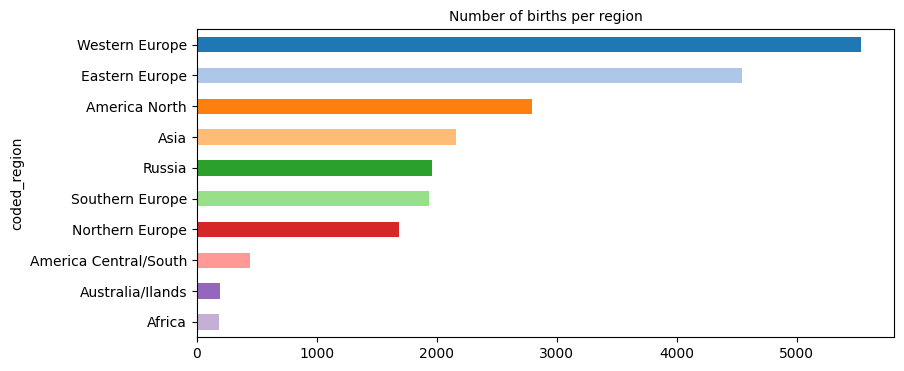

In [21]:
## Distribution of births per region
fig = df_region.number.sort_values().plot(kind='barh', figsize=(9,4), color=rev_col, width=0.5)
fig.set_title('Number of births per region', size=10)
plt.plot()

[]

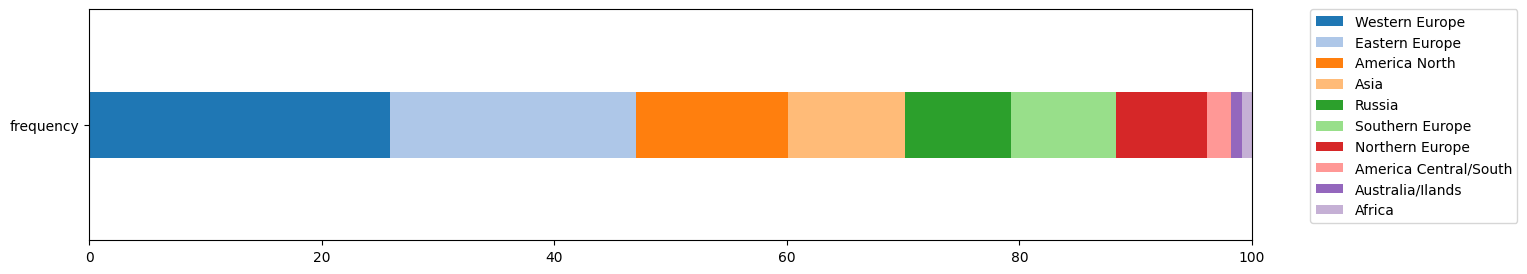

In [23]:
### Pandas plot reference
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html
## Barplots
# https://www.shanelynn.ie/bar-plots-in-python-using-pandas-dataframes/

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

### Transform birth years to periods of activity years

In [24]:
### Create imputed activity year
df_p['activityYear'] = df_p.birthYear.apply(lambda x : int(x)+45)

In [25]:
### Create list of 25 years periods

yr = df_p.activityYear

l_25 = list(range(min(yr), max(yr)+26, 25))
print(l_25[:5],l_25[-5:], len(l_25)-1)

[1826, 1851, 1876, 1901, 1926] [1926, 1951, 1976, 2001, 2026] 8


In [26]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

df_p['per_25'] = pd.cut(df_p['activityYear'], l_25, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
df_p['per_25'] = df_p['per_25'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
df_p.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe,Western Europe,1974,1951-1975
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe,Northern Europe,1937,1926-1950
2,http://www.wikidata.org/entity/Q100153910,Frank J. Blatt,1924,male,Vienna,POINT (16.3725 48.208333),http://www.wikidata.org/entity/Q1741,22,Western Europe,Western Europe,1969,1951-1975


In [27]:
### distribution des naissances par périodes de 25 ans
naissances_per = pd.DataFrame(df_p.groupby(by='per_25').size())
naissances_per.columns=['number']
print(naissances_per)

           number
per_25           
1826-1850     408
1851-1875     574
1876-1900     948
1901-1925    1464
1926-1950    2311
1951-1975    4955
1976-2000    7265
2001-2025    3520


In [28]:
### Add frequency

naissances_per['frequency'] = (100 * naissances_per['number'] \
                                   / naissances_per['number'].sum()).round(2)
naissances_per


,number,frequency
per_25,,
1826-1850,408,1.90
1851-1875,574,2.68
1876-1900,948,4.42
1901-1925,1464,6.83
1926-1950,2311,10.78
1951-1975,4955,23.11
1976-2000,7265,33.88
2001-2025,3520,16.41


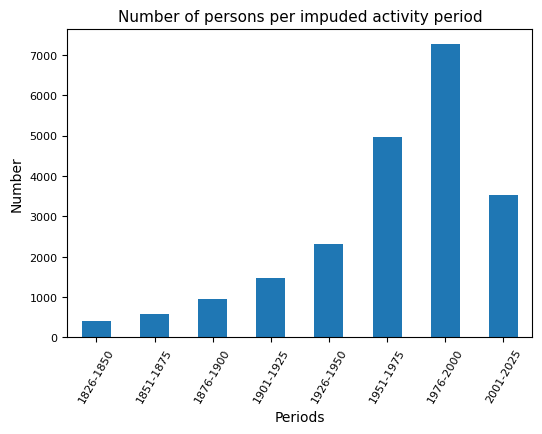

In [29]:
### Distribution by impuded active generations
ax = naissances_per.number.plot(kind='bar',rot=60, fontsize=8, figsize=(6,4))
plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Number of persons per impuded activity period', size=11)
plt.show()

In [30]:
### Transform to one row dataframe
ljt = pd.DataFrame(naissances_per.frequency.sort_index(ascending=True)).T
ljt



per_25,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025
frequency,1.9,2.68,4.42,6.83,10.78,23.11,33.88,16.41


In [32]:
### Créer une palette de couleurs
colors = plt.cm.get_cmap('Blues', 8)(range(8))

[]

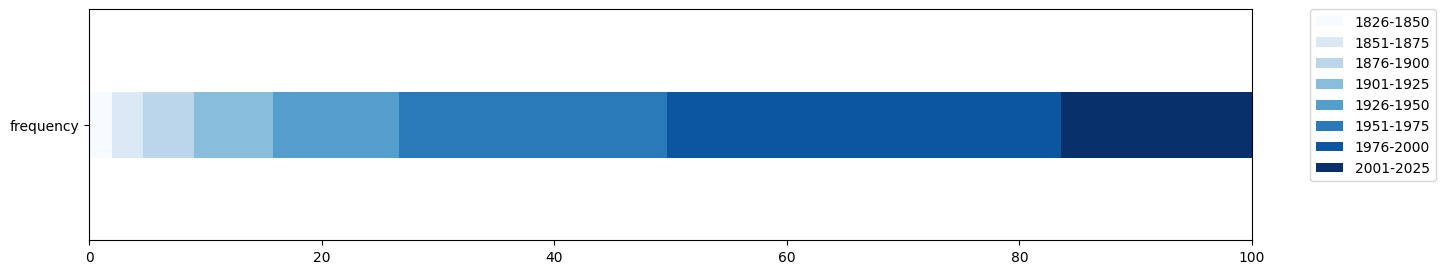

In [35]:
### Frequencies of periods. Total = 100%

fig = ljt.plot(kind='barh', stacked=True, figsize=(15,3), color=colors, width=0.2, xlim=[0,100])
fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
fig.plot()

## Bivariate analysis

In [101]:
### Contingency table: 
# count how many individuals exhibit both of these categories for each of the two variables 
per_vs_region=pd.crosstab(df_p.per_25, df_p.coded_region, margins=True)
per_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_25,,,,,,,,,,,
1826-1850,0,1,17,3,0,69,90,13,52,163,408
1851-1875,0,5,48,6,0,75,98,18,62,262,574
1876-1900,3,13,87,12,4,162,145,51,94,377,948
1901-1925,3,10,205,34,12,245,164,103,149,539,1464
1926-1950,13,25,338,124,19,458,222,234,154,724,2311
1951-1975,34,79,888,507,66,1008,382,556,291,1144,4955
1976-2000,84,176,914,1019,61,1826,404,773,590,1418,7265
2001-2025,51,132,298,456,32,705,182,210,543,911,3520
All,188,441,2795,2161,194,4548,1687,1958,1935,5538,21445


In [102]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X_reg_all_period = per_vs_region.iloc[:-1, :-1 ]

In [103]:
### Calculation of parameters for the chi-square test
statistic, p, dof, expected = stats.chi2_contingency(X_reg_all_period)


In [104]:
### Expected values under independent sampling (H0 hypotheses)
pd.DataFrame(expected).round(1)

,0,1,2,3,4,5,6,7,8,9
0,3.6,8.4,53.2,41.1,3.7,86.5,32.1,37.3,36.8,105.4
1,5.0,11.8,74.8,57.8,5.2,121.7,45.2,52.4,51.8,148.2
2,8.3,19.5,123.6,95.5,8.6,201.0,74.6,86.6,85.5,244.8
3,12.8,30.1,190.8,147.5,13.2,310.5,115.2,133.7,132.1,378.1
4,20.3,47.5,301.2,232.9,20.9,490.1,181.8,211.0,208.5,596.8
5,43.4,101.9,645.8,499.3,44.8,1050.8,389.8,452.4,447.1,1279.6
6,63.7,149.4,946.9,732.1,65.7,1540.7,571.5,663.3,655.5,1876.1
7,30.9,72.4,458.8,354.7,31.8,746.5,276.9,321.4,317.6,909.0


In [105]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 2042.5766574641766 , dof : 63
p-value : 0.0


### Cramér's V (Cramér's phi coefficient)

* We calculate Cramér's V to measure the strength of the association between the two categorical variables.
* Interpretation of values:
  * 0.0-0.1: neglibigle;
  * 0.1-0.3: weak;
  * 0.3-0.5: moderate;
  * &gt; 0.5: strong

$$ 
V = \sqrt{\frac{\chi^2}{n \times \min(r-1, c-1)}} 
$$

* ${\chi^2}$ = 'statistic' in Python *stats* library
* n = number of individuals
* k = normalization Factor (kk):
  * Formula: k=min⁡(r−1,c−1)k (Minimum)
  * Usage: Used only in the denominator of Cramér's V to normalize the score between 0 and 1.



In [106]:
## Cramer test:


# 1. Total sample size (n)
n = per_vs_region.iloc[-1, -1]
# print(n)

# 2. Get the dimensions of the table
r, c = X_reg_all_period.shape

# 3. Calculate the correct denominator: min(rows-1, columns-1)
# Note: The returned ‘dof’ is (r-1)*(c-1); this is not directly the divisor for Cramer's rule
k = min(r - 1, c - 1)
# print(k)

# Avoid dividing by zero if the table is 1x1
if k == 0:
    cramers_v = 0
else:
    # 4. Apply the formula
    cramers_v = np.sqrt(statistic / (n * k))

print(f"Cramer's V : {cramers_v.round(5)}")

Cramer's V : 0.11665


In [107]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X_reg_all_period, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.11664795702420783


In [109]:
# 2. Calculate Adjusted Residuals
observed = X_reg_all_period
row_totals = observed.sum(axis=1).values.reshape(-1, 1)
print(row_totals)
col_totals = observed.sum(axis=0).values.reshape(1, -1)
print(col_totals)
n = observed.sum().sum()

[[ 408]
 [ 574]
 [ 948]
 [1464]
 [2311]
 [4955]
 [7265]
 [3520]]
[[ 188  441 2795 2161  194 4548 1687 1958 1935 5538]]


In [121]:
# Basic formula
residuals = (round((observed-expected)/np.sqrt(expected),2))
residuals

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1826-1850,-1.89,-2.55,-4.96,-5.94,-1.92,-1.88,10.22,-3.97,2.50,5.62
1851-1875,-2.24,-1.98,-3.10,-6.82,-2.28,-4.24,7.86,-4.75,1.42,9.34
1876-1900,-1.84,-1.47,-3.29,-8.55,-1.56,-2.75,8.15,-3.82,0.91,8.45
1901-1925,-2.75,-3.66,1.03,-9.35,-0.34,-3.72,4.55,-2.65,1.47,8.28
1926-1950,-1.61,-3.27,2.12,-7.13,-0.42,-1.45,2.98,1.58,-3.78,5.21
1951-1975,-1.43,-2.27,9.53,0.34,3.16,-1.32,-0.39,4.87,-7.38,-3.79
1976-2000,2.55,2.18,-1.07,10.60,-0.58,7.27,-7.01,4.26,-2.56,-10.58
2001-2025,3.63,7.01,-7.51,5.38,0.03,-1.52,-5.70,-6.21,12.65,0.07


In [120]:
# Formula for Adjusted Residuals
residuals = (observed - expected) / np.sqrt(expected * (1 - row_totals/n) * (1 - col_totals/n))
residuals.round(1)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_25,,,,,,,,,,
1826-1850,-1.9,-2.6,-5.4,-6.3,-1.9,-2.1,10.8,-4.2,2.6,6.6
1851-1875,-2.3,-2.0,-3.4,-7.3,-2.3,-4.8,8.3,-5.1,1.5,11.0
1876-1900,-1.9,-1.5,-3.6,-9.2,-1.6,-3.2,8.7,-4.1,1.0,10.0
1901-1925,-2.9,-3.8,1.1,-10.2,-0.4,-4.3,4.9,-2.9,1.6,10.0
1926-1950,-1.7,-3.5,2.4,-8.0,-0.4,-1.7,3.3,1.8,-4.2,6.4
1951-1975,-1.6,-2.6,11.7,0.4,3.6,-1.7,-0.5,5.8,-8.8,-5.0
1976-2000,3.1,2.7,-1.4,13.8,-0.7,10.1,-9.0,5.5,-3.3,-15.1
2001-2025,4.0,7.7,-8.8,6.2,0.0,-1.9,-6.5,-7.1,14.5,0.1


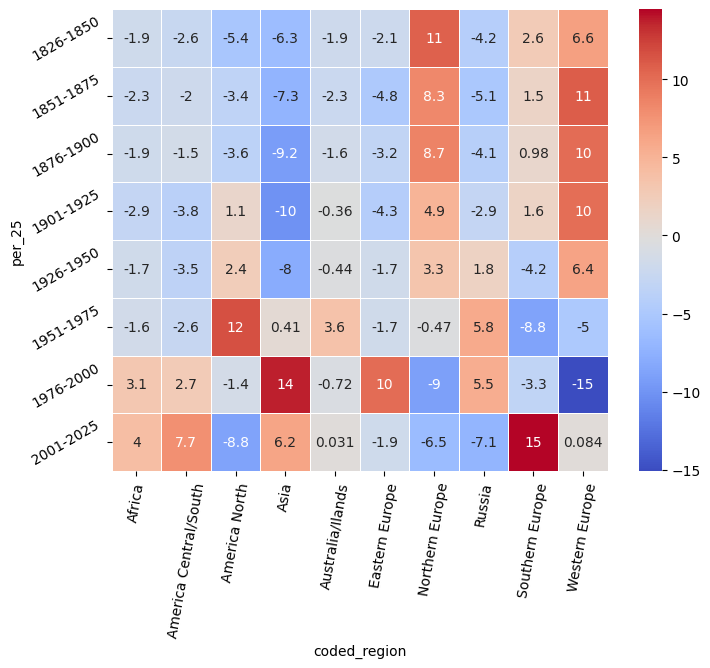

In [119]:
table=residuals
fig, ax = plt.subplots(figsize=(8,6))         
# Sample figsize in inches
g = sns.heatmap(table, annot=table, cmap="coolwarm", linewidths=.5, ax=ax)
labels = table.index
p = g.set_yticklabels(labels, rotation=30)
labels_cols = table.columns
p = g.set_xticklabels(labels_cols, rotation=80)

plt.show()



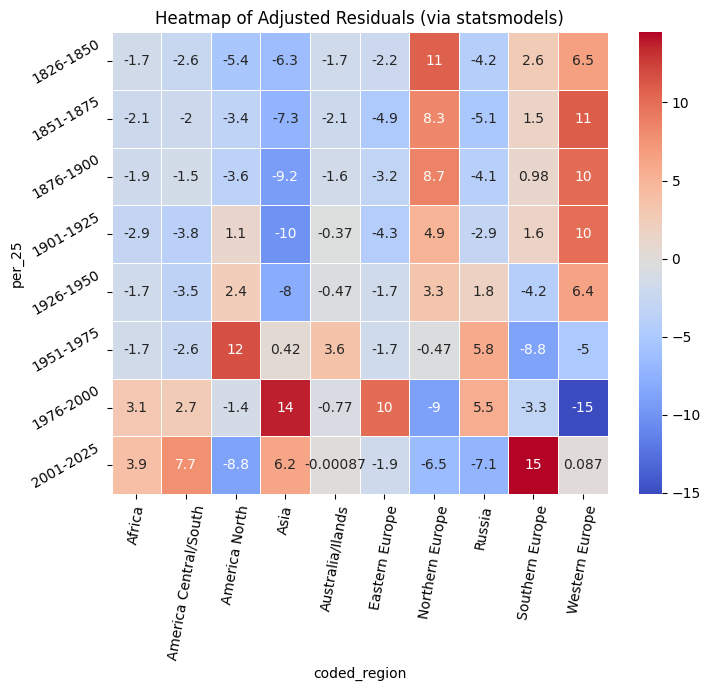

In [75]:
### Using statmodels (sm)

# 1. Create the Table object directly from your data
table = sm.stats.Table(X_reg_all_period)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(8,6))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


## Bivariate analysis genders

In [84]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['female', 'male'])]

In [85]:
gender_vs_region=pd.crosstab(df_pg.gender, df_pg.coded_region, margins=True)
gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
gender,,,,,,,,,,,
female,30,91,301,136,16,312,145,99,208,322,1660
male,157,349,2488,1962,176,4231,1540,1855,1722,5206,19686
All,187,440,2789,2098,192,4543,1685,1954,1930,5528,21346


In [86]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = gender_vs_region.iloc[:-1, :-1 ]

In [87]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [88]:
pd.DataFrame(expected).round(1)

,0,1,2,3,4,5,6,7,8,9
0,14.5,34.2,216.9,163.2,14.9,353.3,131.0,152.0,150.1,429.9
1,172.5,405.8,2572.1,1934.8,177.1,4189.7,1554.0,1802.0,1779.9,5098.1


In [89]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 240.7913302914687 , dof : 9
p-value : 8.750317956356992e-47


In [94]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.10620920803943215


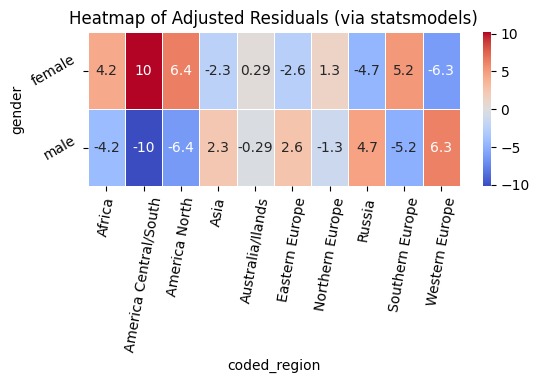

In [98]:
import statsmodels.api as sm

# 1. Create the Table object directly from your data
table = sm.stats.Table(X)

# 2. Get Adjusted Residuals instantly (no manual formula needed)
adjusted_resids = table.standardized_resids
# 3. Plot
fig, ax = plt.subplots(figsize=(6,2))         
# Sample figsize in inches
ax = sns.heatmap(adjusted_resids, annot=adjusted_resids, cmap="coolwarm", linewidths=.5, ax=ax)
labels = adjusted_resids.index
p = ax.set_yticklabels(labels, rotation=30)
labels_cols = adjusted_resids.columns
p = ax.set_xticklabels(labels_cols, rotation=80)

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()


## Bivariate analysis genders+generations vs regions

In [187]:
## filter to only retain statistically significant categories, 
# given the obeserved distribution
df_pg = df_p[df_p['gender'].isin(['female', 'male'])]
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe,Western Europe,1974,1951-1975
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe,Northern Europe,1937,1926-1950


In [188]:
def code_gender_period(gender: str):
    if gender == 'female':
        output='f'
    else:
        output='m'
    return output    

In [189]:
df_pg['per_gender']= df_pg.apply(lambda x: x.per_25 +'_'+ code_gender_period(x.gender), axis=1)
df_pg.head(2)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,FID,REGION,coded_region,activityYear,per_25,per_gender
0,http://www.wikidata.org/entity/Q1000193,Hans Elsässer,1929,male,Aalen,POINT (10.093611 48.837222),http://www.wikidata.org/entity/Q3951,22,Western Europe,Western Europe,1974,1951-1975,1951-1975_m
1,http://www.wikidata.org/entity/Q1000934,Charles Christian Lauritsen,1892,male,Holstebro,POINT (8.6175 56.358056),http://www.wikidata.org/entity/Q27678,24,Northern Europe,Northern Europe,1937,1926-1950,1926-1950_m


In [190]:
per_gender_vs_region=pd.crosstab(df_pg.per_gender, df_pg.coded_region, margins=True)
per_gender_vs_region

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe,All
per_gender,,,,,,,,,,,
1826-1850_f,0,0,0,0,0,0,3,0,0,0,3
1826-1850_m,0,1,17,3,0,69,87,13,52,163,405
1851-1875_f,0,0,3,0,0,0,5,0,1,0,9
1851-1875_m,0,5,45,6,0,75,93,18,61,262,565
1876-1900_f,0,0,6,1,0,1,6,2,0,1,17
1876-1900_m,3,13,81,11,4,161,139,49,94,375,930
1901-1925_f,0,0,29,0,0,6,17,4,1,8,65
1901-1925_m,3,10,176,33,12,239,147,99,148,531,1398
1926-1950_f,1,3,48,4,0,23,15,17,13,54,178


In [191]:
### All the period but with less regions
# X_reg_all_period = per_vs_region.loc[:, per_vs_region.iloc[-1] > 500].iloc[:-1, :-1 ]
X = per_gender_vs_region.iloc[:-1, :-1 ]

In [192]:
### Calcul des paramètres pour le test du Chi-2
statistic, p, dof, expected = stats.chi2_contingency(X)


In [196]:
### For significant chi-2 test minimal number in each cell of expected:5
# bias in the results
pd.DataFrame(expected).round(1)

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.1,0.4,0.3,0.0,0.6,0.2,0.3,0.3,0.8
1,3.5,8.3,52.9,39.8,3.6,86.2,32.0,37.1,36.6,104.9
2,0.1,0.2,1.2,0.9,0.1,1.9,0.7,0.8,0.8,2.3
3,4.9,11.6,73.8,55.5,5.1,120.2,44.6,51.7,51.1,146.3
4,0.1,0.4,2.2,1.7,0.2,3.6,1.3,1.6,1.5,4.4
5,8.1,19.2,121.5,91.4,8.4,197.9,73.4,85.1,84.1,240.8
6,0.6,1.3,8.5,6.4,0.6,13.8,5.1,6.0,5.9,16.8
7,12.2,28.8,182.7,137.4,12.6,297.5,110.4,128.0,126.4,362.0
8,1.6,3.7,23.3,17.5,1.6,37.9,14.1,16.3,16.1,46.1
9,18.6,43.8,277.5,208.8,19.1,452.0,167.7,194.4,192.0,550.1


In [197]:
print('Chi2 :', statistic, ', dof :',dof)
print('p-value :', p)

Chi2 : 2467.0847508588377 , dof : 135
p-value : 0.0


In [198]:
### Cramér's phi coefficient
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.contingency.association.html
vc = stats.contingency.association(X, method='cramer')
print('Cramèr\'s V:', vc)

Cramèr's V: 0.11332155549667376


In [204]:
### Standaradized chi-2 contribution
# Basic formula
std_res = (round((X-expected)/np.sqrt(expected),2))
std_res.head(2)

coded_region,Africa,America Central/South,America North,Asia,Australia/Ilands,Eastern Europe,Northern Europe,Russia,Southern Europe,Western Europe
per_gender,,,,,,,,,,
1826-1850_f,-0.16,-0.25,-0.63,-0.54,-0.16,-0.80,5.68,-0.52,-0.52,-0.88
1826-1850_m,-1.88,-2.54,-4.94,-5.83,-1.91,-1.85,9.73,-3.95,2.54,5.67


In [ ]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Residuals")
plt.show()

## Montecarlo test




In [166]:
### Test version Monte Carlo

pivot=X

# Monte Carlo p-value

chi2_obs, _, _, _ = stats.chi2_contingency(pivot, lambda_="pearson")

n_simulations = 10_000
count = 0
valid_sims = 0
n = pivot.sum().sum()
expected_probs = np.outer(pivot.sum(axis=1), 
                          pivot.sum(axis=0)) / n**2

while valid_sims < n_simulations:
    simulated = np.random.multinomial(n, expected_probs.ravel()).reshape(pivot.shape)
    
    if simulated.sum(axis=1).min() == 0 or simulated.sum(axis=0).min() == 0:
        continue
    
    try:
        chi2_sim, _, _, _ = stats.chi2_contingency(simulated, lambda_="pearson")
        if chi2_sim >= chi2_obs:
            count += 1
        valid_sims += 1
    except ValueError:
        continue

p_monte_carlo = count / n_simulations
print(f"Observed chi²: {chi2_obs:.4f}")
print(f"Monte Carlo p-value ({n_simulations} simulations): {p_monte_carlo:.4f}")

Observed chi²: 2467.0848
Monte Carlo p-value (10000 simulations): 0.0000


In [167]:
def cramers_v_corrected(ct):
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.values.sum()
    r, c = ct.shape
    
    phi2 = chi2 / n
    # bias correction
    phi2_corr = max(0, phi2 - ((r-1)*(c-1)) / (n-1))
    r_corr = r - (r-1)**2 / (n-1)
    c_corr = c - (c-1)**2 / (n-1)
    
    return np.sqrt(phi2_corr / min(r_corr - 1, c_corr - 1))

In [168]:
print(cramers_v_corrected(pivot)) 

0.11020052071796353


In [169]:
grand_total = pivot.values.sum()
row_margin = (pivot.sum(axis=1) / grand_total).values  # shape (n_rows,)
col_margin = (pivot.sum(axis=0) / grand_total).values  # shape (n_cols,)
# print(grand_total, row_margin, col_margin)
correction = np.outer(1 - row_margin, 1 - col_margin)
#print(correction)

In [ ]:
### Due to the limit on the number of individuals, we adjust the table for independence using the coefficient calculated earlier

table = (pivot - expected) / np.sqrt(expected * correction)

In [ ]:
# 3. Plot
fig, ax = plt.subplots(figsize=(8,8))         

# Create heatmap
sns.heatmap(
    table, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax,
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=20, va='center')

ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.show()

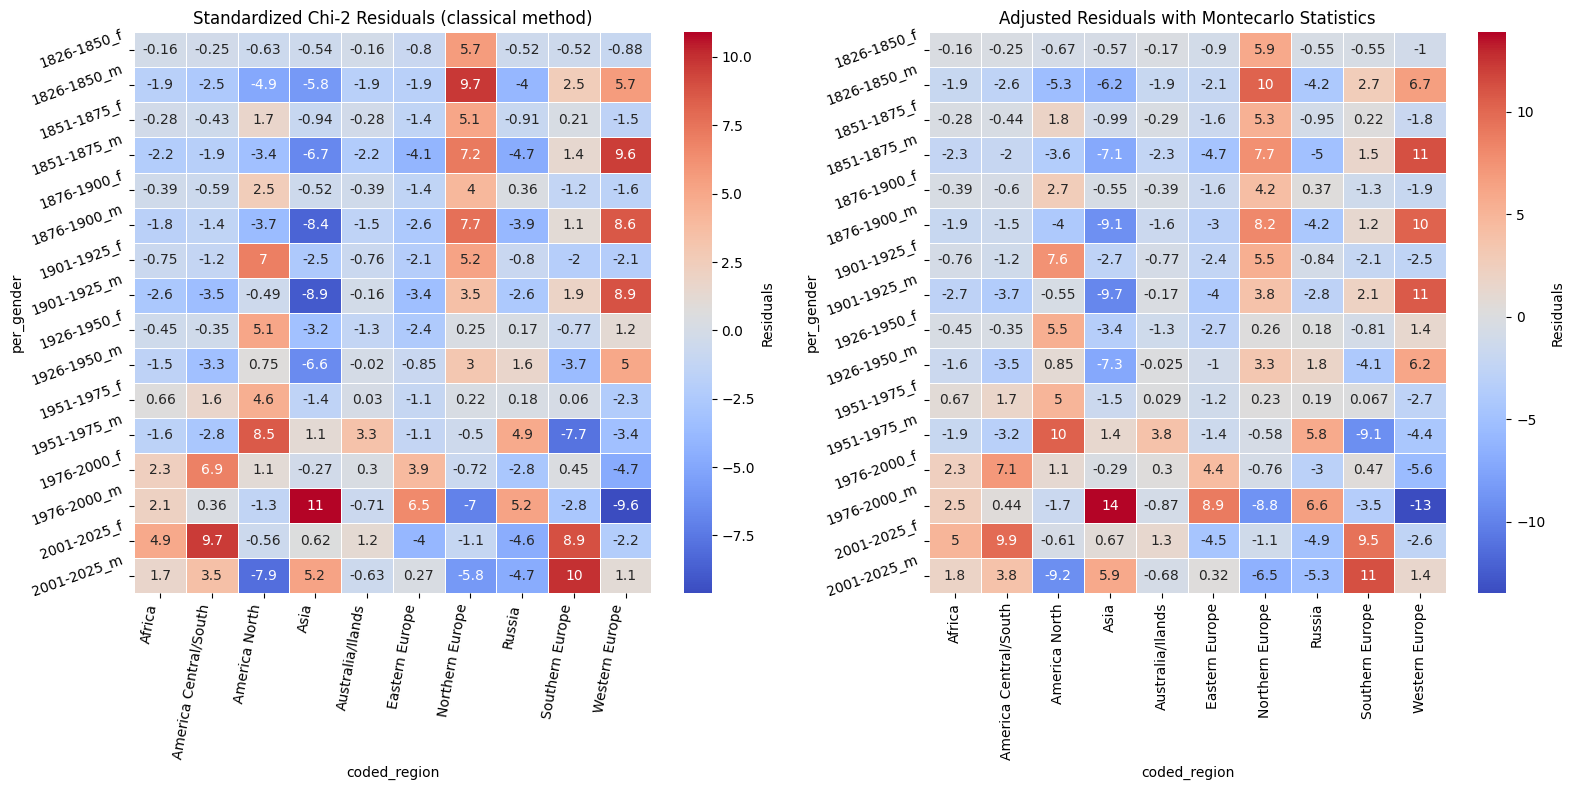

In [207]:
### Due to the limit on the number of individuals, we adjust the table for independence using the coefficient calculated earlier

table = (pivot - expected) / np.sqrt(expected * correction)

# 3. Plot
fig, ax = plt.subplots(1,2,figsize=(16,8))         

# Create heatmap
sns.heatmap(
    std_res, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[0],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=80, ha='right')
ax[0].set_yticklabels(ax[0].get_yticklabels(), rotation=20, va='center')
ax[0].set_title("Standardized Chi-2 Residuals (classical method)", fontsize=12)


# Create heatmap
sns.heatmap(
    table, 
    annot=True,            # Use boolean True to annotate with data values
    cmap="coolwarm", 
    linewidths=.5, 
    ax=ax[1],
    cbar_kws={'label': 'Residuals'}
)
# 3. Fix Label Rotation (Safe Method)
# This rotates existing ticks without risking a count mismatch
#ax.set_xticklabels(ax.get_xticklabels(), rotation=80, ha='right')
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=20, va='center')
ax[1].set_title("Adjusted Residuals with Montecarlo Statistics", fontsize=12)

# ax.set_title("Heatmap of Adjusted Residuals (via statsmodels)")
plt.tight_layout()
plt.show()